In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models # add models to the list
from torchvision.utils import make_grid
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

/home/zeineddine/anaconda3/envs/torchEnv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
train_transform=transforms.Compose([
        transforms.RandomRotation(10),      # rotate +/- 10 degrees
        transforms.RandomHorizontalFlip(),  # reverse 50% of images
        transforms.Resize((224,224)),             # resize shortest side to 224 pixels
        #transforms.CenterCrop(224),         # crop longest side to 224 pixels at center
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
])

In [ ]:
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    #transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
train_data=datasets.ImageFolder(root=("data/dog_vs_cat/dataset/training_set"),transform=train_transform)

In [ ]:
test_data=datasets.ImageFolder(root=("data/dog_vs_cat/dataset/test_set"),transform=test_transform)

In [ ]:
class_names=train_data.classes

In [ ]:
batch_size=200
train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)

test_loader=DataLoader(test_data,batch_size=batch_size,shuffle=True)

In [ ]:
len(train_data)

8000

In [ ]:
len(test_data)

2000

In [ ]:
for images, labels in train_loader:
    break
images=images[0:10,:,:,:]
labels=labels[0:10]
#print the labels
print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))
im=make_grid(images,nrow=5)

Label: [1 1 1 1 0 0 0 0 1 1]
Class: dogs dogs dogs dogs cats cats cats cats dogs dogs


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


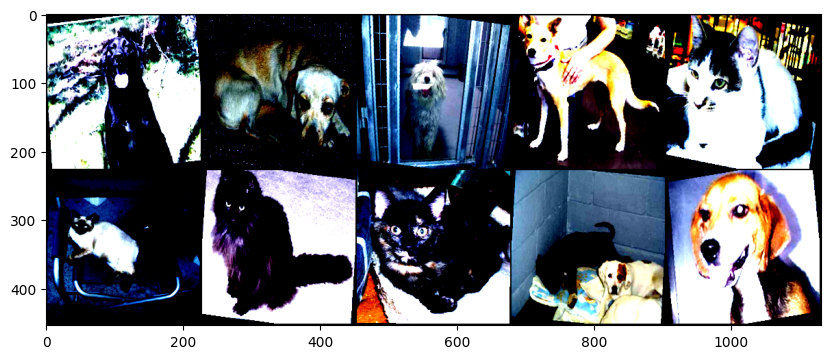

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

In [ ]:
inv_normalize=transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225],
                                 std=[1/0.229,1/0.224,1/0.225])
im=inv_normalize(im)

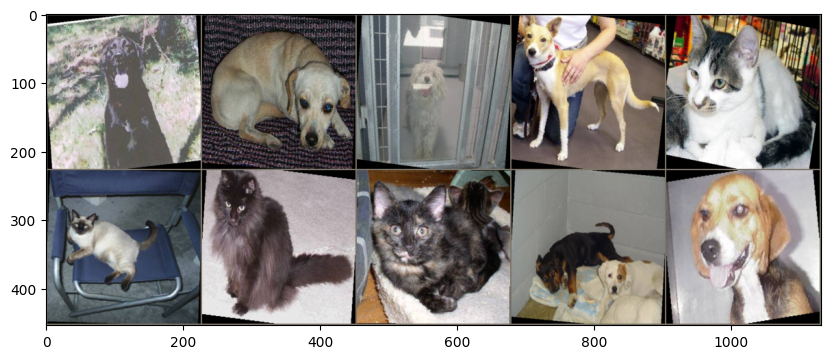

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

In [ ]:
class ConvolutionalNetwork(nn.Module): #Building our own convolutional neural network
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,40,3)
        self.conv2=nn.Conv2d(40,20,3)
        self.fc1=nn.Linear(20*54*54,128)  #building with 120 neurons
        self.fc2=nn.Linear(128,32)
        self.fc3=nn.Linear(32,2)
    def forward(self,X):
        X=F.relu(self.conv1(X))
        X=F.max_pool2d(X,2,2)
        X=F.relu(self.conv2(X))
        X=F.max_pool2d(X,2,2)
        X=nn.Flatten()(X)#X=X.view(-1,20*54*54)# similar to Flatten
        X=F.relu(self.fc1(X))
        X=F.relu(self.fc2(X))
        X=self.fc3(X)

        return F.log_softmax(X, dim=1)



In [ ]:
CNNmodel=ConvolutionalNetwork()
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(CNNmodel.parameters(),lr=0.001) #We would be using adam as an optimizer

In [ ]:
CNNmodel

ConvolutionalNetwork(
  (conv1): Conv2d(3, 40, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(40, 20, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=58320, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)

In [ ]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>8}')
    print(f'________\n{sum(params):>8}')
count_parameters(CNNmodel)

    1080
      40
    7200
      20
 7464960
     128
    4096
      32
      64
       2
________
 7477622


In [ ]:
import time
start_time=time.time()
train_losses=[]
test_losses=[]
train_correct=[]
test_correct=[]
epochs=10
CNNmodel.to(device)
best_val_acc=0
for i in range(epochs):
    trn_corr=0
    tst_corr=0
    for b, (X_train,y_train) in enumerate(train_loader):  #Training our model on images and then testing our model with
        b+=1
        X_train=X_train.to(device)
        y_train=y_train.to(device)
        y_pred=CNNmodel(X_train)
        loss=criterion(y_pred,y_train)
        #true predictions
        predicted=torch.max(y_pred.data,1)[1]
        batch_corr=(predicted==y_train).sum()
        trn_corr+=batch_corr

        #update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print interim results

    print(f"epoch: {i} loss: {loss.item} batch: {b} accuracy: {trn_corr.item()*100/(batch_size*b):7.3f}%")
    loss=loss.detach().cpu().numpy()
    train_losses.append(loss)
    train_correct.append(trn_corr)


    with torch.no_grad():
        for b, (X_test,y_test) in enumerate(test_loader):
            X_test=X_test.to(device)
            y_test=y_test.to(device)
            y_val=CNNmodel(X_test)
            loss=criterion(y_val,y_test)

            predicted=torch.max(y_val.data,1)[1]
            btach_corr=(predicted==y_test).sum()
            tst_corr+=btach_corr
        val_acc=tst_corr.item()*100/(batch_size*b)
        loss=loss.detach().cpu().numpy()
        test_losses.append(loss)
        test_correct.append(tst_corr)
        if best_val_acc<val_acc:
          best_val_acc=val_acc
          torch.save(CNNmodel.state_dict(),"/home/zeineddine/Courses/Deep Learning/TP/pretrained/best_mode_weight_CNN_dogs_cats.pth")
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

epoch: 0 loss: <built-in method item of Tensor object at 0x7f84c84101d0> batch: 40 accuracy:  54.288%
epoch: 1 loss: <built-in method item of Tensor object at 0x7f84c8312480> batch: 40 accuracy:  58.300%
epoch: 2 loss: <built-in method item of Tensor object at 0x7f84c8313060> batch: 40 accuracy:  64.612%
epoch: 3 loss: <built-in method item of Tensor object at 0x7f84c8310180> batch: 40 accuracy:  67.412%
epoch: 4 loss: <built-in method item of Tensor object at 0x7f84c8309a30> batch: 40 accuracy:  68.537%
epoch: 5 loss: <built-in method item of Tensor object at 0x7f84c830b6f0> batch: 40 accuracy:  71.638%
epoch: 6 loss: <built-in method item of Tensor object at 0x7f84c8308e00> batch: 40 accuracy:  73.225%
epoch: 7 loss: <built-in method item of Tensor object at 0x7f84c8309620> batch: 40 accuracy:  75.638%
epoch: 8 loss: <built-in method item of Tensor object at 0x7f84c830b470> batch: 40 accuracy:  77.312%
epoch: 9 loss: <built-in method item of Tensor object at 0x7f84c830b600> batch: 40

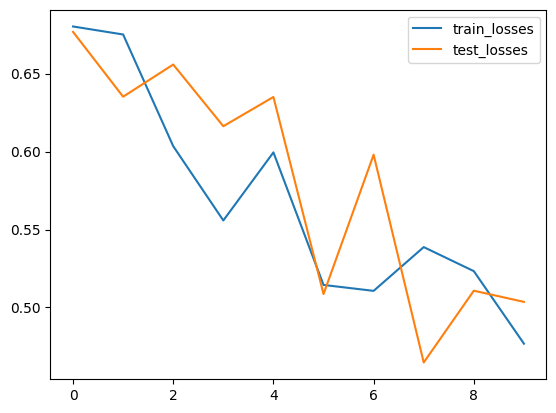

In [ ]:
plt.plot(train_losses,label="train_losses")
plt.plot(test_losses,label="test_losses")
plt.legend()

In [ ]:
CNNModelLoaded=ConvolutionalNetwork()
CNNModelLoaded.load_state_dict(torch.load("/home/zeineddine/Courses/Deep Learning/TP/pretrained/best_mode_weight_CNN_dogs_cats.pth"))

<All keys matched successfully>

Predicted value: 0 cats


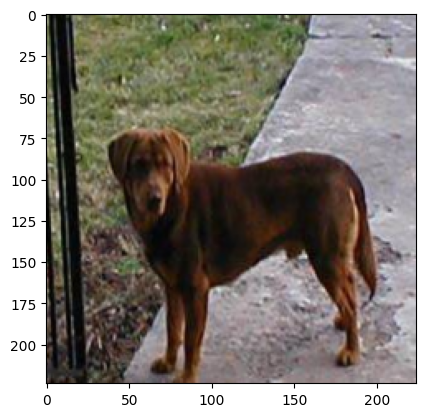

In [ ]:
#Evaluating our CNN model
CNNmodel.eval()
nb=1256
with torch.no_grad():
    new_pred=CNNmodel(test_data[nb][0].to(device).view(1,3,224,224)).argmax()
    plt.imshow(np.transpose(inv_normalize(test_data[nb][0]).numpy(),(1,2,0)))
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

In [ ]:
def image_convert(img):
    img = img.clone().cpu().numpy()
    img = img.transpose(1,2,0)
    std = [0.5,0.5,0.5]
    mean = [0.5,0.5,0.5]
    img = img*std + mean
    return img


def plot_10():
        iter_ = iter(train_loader)
        images,labels = next(iter_)
        an_ = {'0':'cat','1':'dog'}

        plt.figure(figsize=(20,10))
        for idx in range(10):
            plt.subplot(2,5,idx+1)
            img = image_convert(images[idx])
            label = labels[idx]
            plt.imshow(img)
            plt.title(an_[str(label.numpy())])
        plt.show()

def plot_val_images():

    label_dict = ['cat','dog']

    iter_ = iter(test_loader)
    images,labels = next(iter_)
    images = images.to(device)
    pred_labels = labels.to(device)


    img_out = CNNmodel(images)
    value, index_val = torch.max(img_out, 1)

    # label = label_dict[str(label)]
    fig = plt.figure(figsize=(35,9))
    for idx in np.arange(10):
        ax = fig.add_subplot(2,5,idx+1)
        plt.imshow(image_convert(images[idx]))
        label = labels[idx]
        pred_label = index_val[idx]
        ax.set_title('Act {},pred {}'.format(label_dict[label],label_dict[pred_label]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

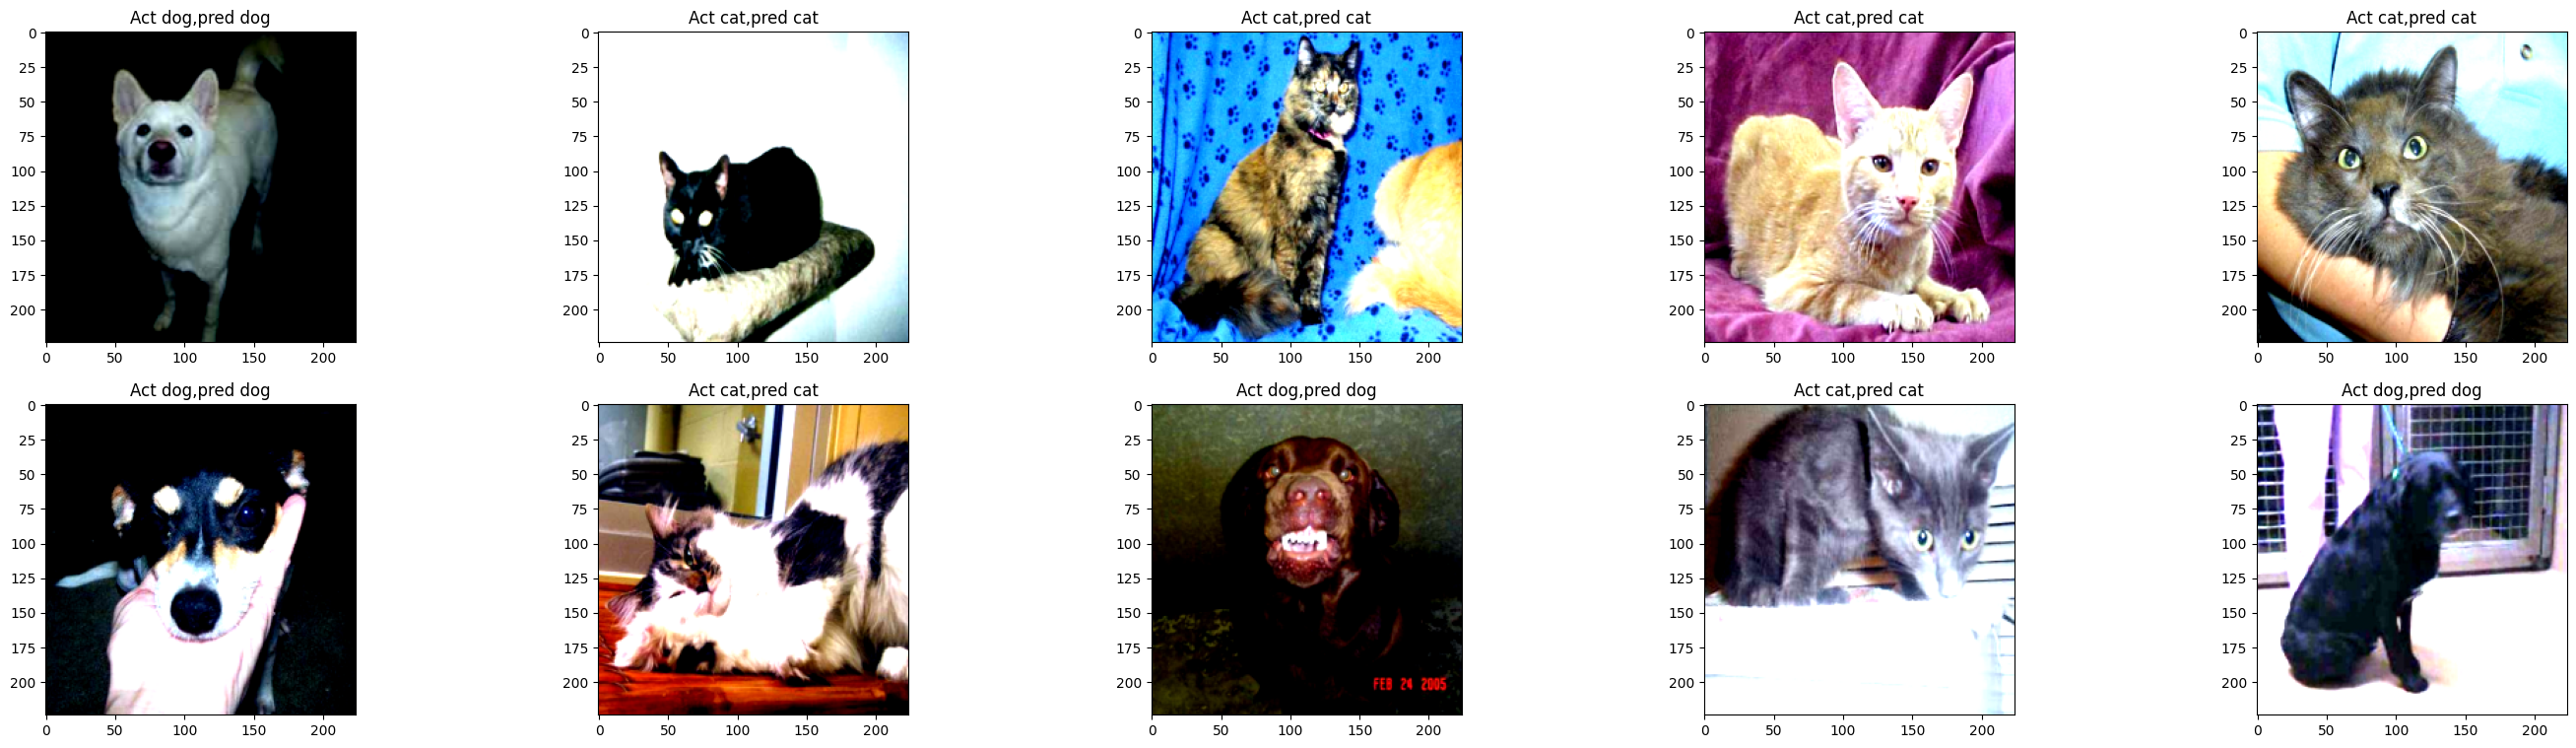

In [ ]:
plot_val_images()